In [ ]:
import numpy as np
np.set_printoptions(precision=4, suppress=True)

import matplotlib.pyplot as plt

In [ ]:
A = np.array([
    [-4, 10, -1, -7,  3],
    [-3, 10, -1, -6,  2],
    [-4, 11, -1, -5,  1],
    [-4, 10,  0, -4,  0],
    [-4, 10, -1, -2, -1]
], dtype=float)

S = np.array([
    [11, 1, 1,  5, 31],
    [ 6, 1, 2,  9, 46],
    [ 9, 2, 3, 12, 53],
    [ 8, 2, 4, 14, 56],
    [ 9, 3, 5, 15, 57]
], dtype=float)

x0 = np.array([1, 1, 1, 1, 1], dtype=float)

In [ ]:
def to_hessenberg(A):
    n = A.shape[0]
    H = A.copy()
    for i in range(n - 2):
        x = H[i+1:, i]
        e1 = np.zeros_like(x)
        e1[0] = np.linalg.norm(x) * (1 if x[0] >= 0 else -1)
        v = x + e1
        v = v / np.linalg.norm(v)
        H[i+1:, i:] -= 2 * np.outer(v, v @ H[i+1:, i:])
        H[:, i+1:] -= 2 * (H[:, i+1:] @ v).reshape(-1, 1) @ v.reshape(1, -1)
    return H

def givens_qr_step(H_sub, shift):
    n = H_sub.shape[0]
    Q = np.eye(n)
    R = H_sub - shift * np.eye(n)
    for i in range(n - 1):
        a, b = R[i, i], R[i+1, i]
        r = np.sqrt(a**2 + b**2)
        if r == 0:
            continue
        c, s = a / r, -b / r
        G = np.array([[c, -s], [s, c]])
        R[i:i+2, i:] = G @ R[i:i+2, i:]
        Q_curr = np.eye(n)
        Q_curr[i:i+2, i:i+2] = G.T
        Q = Q @ Q_curr
    return (R @ Q) + shift * np.eye(n)

def qr_algorithm(A, tol=1e-12, max_iter=1000):
    n = A.shape[0]
    H = to_hessenberg(A)
    for k in range(max_iter):
        for i in range(n - 1):
            if abs(H[i+1, i]) < tol * (abs(H[i, i]) + abs(H[i+1, i+1])):
                H[i+1, i] = 0.0
        if np.allclose(np.tril(H, -1), 0, atol=tol):
            break
        shift = H[-1, -1]
        H = givens_qr_step(H, shift)
    eigenvalues = np.sort(np.diag(H))
    return eigenvalues

In [ ]:
eigenvalues = qr_algorithm(A)

In [ ]:
print("Собственные значения матрицы A:")
print(eigenvalues)
print(np.linalg.eigvals(A))

Собственные значения матрицы A:
[-2. -1.  0.  1.  2.]
[-2. -1.  0.  1.  2.]


In [ ]:
Lambda = np.diag(eigenvalues)
S_inv = np.linalg.inv(S)
A_reconstructed = S @ Lambda @ S_inv
residual = np.linalg.norm(A - A_reconstructed)

print("Проверка равенства A = S * Λ * S^(-1):")
print(f"Невязка: {residual:.2e}")
print()

Проверка равенства A = S * Λ * S^(-1):
Невязка: 5.25e-11



In [ ]:
def solve_ode(t, eigenvalues, S, x0):
    S_inv = np.linalg.inv(S)
    y0 = S_inv @ x0
    result = np.zeros((len(t), len(x0)))
    for i, ti in enumerate(t):
        exp_diag = np.diag(np.exp(eigenvalues * ti))
        y = exp_diag @ y0
        result[i] = S @ y
    return result

t_large = np.linspace(0, 100, 100)
sol_large = solve_ode(t_large, eigenvalues, S, x0)

print("Поведение системы для t -> +inf:")
print(f"x({t_large[-1]:.1f}) = {sol_large[-1]}")
print()

max_abs_last = np.max(np.abs(sol_large[-1]))
if max_abs_last > 1e6:
    print("Система неустойчива (решение неограниченно растет)")
elif max_abs_last < 1e-6:
    print("Система устойчива (решение стремится к нулю)")
elif np.allclose(sol_large[-1], sol_large[-2], rtol=1e-5):
    print("Система устойчива (решение стремится к стационарной точке)")
else:
    print("Система неустойчива")
print()

Поведение системы для t -> +inf:
x(100.0) = [9.3335e+86 1.3850e+87 1.5957e+87 1.6861e+87 1.7162e+87]

Система неустойчива (решение неограниченно растет)



Вариант (a): решение стремится к ненулевой точке
Модифицированные собственные значения: [-2.  -1.5 -1.  -0.5  0. ]
Модифицированная матрица A_a:
[[-3.   5.  -0.5 -3.5  1.5]
 [-1.5  4.  -0.5 -3.   1. ]
 [-2.   5.5 -1.5 -2.5  0.5]
 [-2.   5.   0.  -3.  -0. ]
 [-2.   5.  -0.5 -1.  -1.5]]

Вариант (b): решение стремится к нулю
Модифицированные собственные значения: [-3.  -2.  -1.5 -1.  -0.5]
Модифицированная матрица A_b:
[[-4.4167  5.9167 -0.0417 -4.6458  1.9583]
 [-2.      4.     -0.25   -3.625   1.25  ]
 [-2.75    6.25   -1.625  -3.4375  0.875 ]
 [-2.6667  5.6667  0.3333 -4.3333  0.3333]
 [-2.75    5.75   -0.125  -1.9375 -1.625 ]]



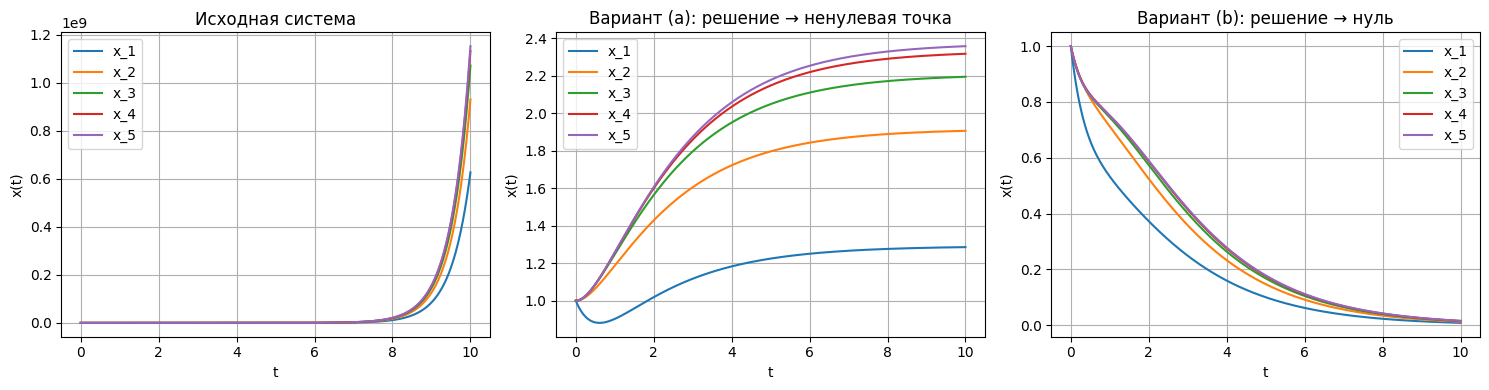

In [ ]:
eigenvalues_a = np.array([-2.0, -1.5, -1.0, -0.5, 0.0])
Lambda_a = np.diag(eigenvalues_a)
A_a = S @ Lambda_a @ np.linalg.inv(S)

print("Вариант (a): решение стремится к ненулевой точке")
print("Модифицированные собственные значения:", eigenvalues_a)
print("Модифицированная матрица A_a:")
print(A_a)
print()

eigenvalues_b = np.array([-3.0, -2.0, -1.5, -1.0, -0.5])
Lambda_b = np.diag(eigenvalues_b)
A_b = S @ Lambda_b @ np.linalg.inv(S)

print("Вариант (b): решение стремится к нулю")
print("Модифицированные собственные значения:", eigenvalues_b)
print("Модифицированная матрица A_b:")
print(A_b)
print()

t_solution = np.linspace(0, 10, 500)
sol_orig = solve_ode(t_solution, eigenvalues, S, x0)
sol_a = solve_ode(t_solution, eigenvalues_a, S, x0)
sol_b = solve_ode(t_solution, eigenvalues_b, S, x0)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
for i in range(5):
    plt.plot(t_solution, sol_orig[:, i], label=f'x_{i+1}')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Исходная система')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
for i in range(5):
    plt.plot(t_solution, sol_a[:, i], label=f'x_{i+1}')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Вариант (a): решение → ненулевая точка')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
for i in range(5):
    plt.plot(t_solution, sol_b[:, i], label=f'x_{i+1}')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Вариант (b): решение → нуль')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()